# Homework 5 Coding Part 2 - DQN

## CartPole Problem (Deep Q-learning)

In this assignment, we will solve the "CartPole-v1" task from the OpenAI Gym using the Deep Q-Network (DQN) algorithm.

### Problem Desciption

A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The system is controlled by applying a force of +1 or -1 to the cart. The pendulum starts upright, and the goal is to prevent it from falling over.


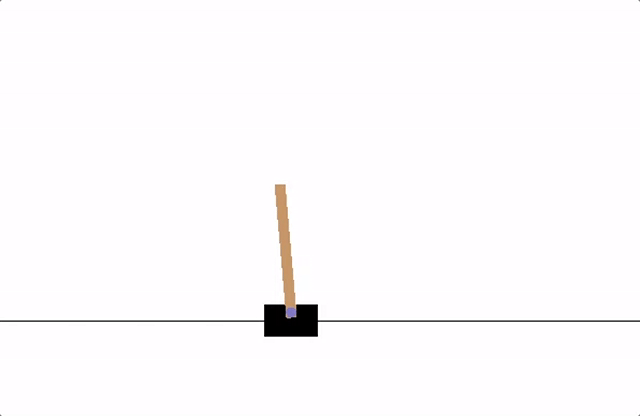




### Formulation

- *State* $s$:
    The state consists of four observations as follows:

|Num|Observation|Min|Max|
|:-:|:-:|:-:|:-:|
|0|Cart Position|-4.8|4.8|
|1|Cart Velocity|-Inf|Inf|
|2|Pole Angle|-0.418 rad(-24 deg)|0.418 rad (24 deg)|
|3|Pole Angular Velocity|-Inf|Inf|

All observations of the initial state are assigned a uniform random value in [-0.05,0.05].


- *Action $a$*:
    There are two possible actions as follows:

|Num|Action|
|:-:|:-:|
|0|Push cart to the left|
|1|Push cart to the right|


- *Reward $r(s,a)$*:
    
    Reward is 1 for every step taken, including the termination step.
    

- Episode Termination

    An episode terminates when one of the following occurs:
  - Pole Angle is more than 12 degrees.
  - Cart Position is more than 2.4 (Cart reaches the edge of the display).
  - Episode length is greater than 500.


- *Objective*:

    The CarPole problem is considered solved when the average return is greater than or equal to 475.0 over 100 consecutive trials (episodes).


In [ ]:
# Import packages. Run this cell.

import numpy as np
import gym
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random

### Tasks

**DQN** (20 points)

We will use DQN algorithm to solve the CartPole problem.

Please complete functions  ``select_action(self, state)`` and  ``train(self, s0, a0, r, s1, done)`` in the class ``DQN``.
   - ``select_action(self, state)`` will be called each step and returns an action for the agent to take.
   - ``train(self, s0, a0, r, s1, done)`` will be called each step after the agent takes an action ``a0`` in the current state ``s0``, receives a reward ``r``, and observes the next state ``s1``. ``done=True`` means that the episode terminates and ``done=False`` means that the episode does not terminate.
   
You can also add or revise classes and functions if you need.

**Note**: The platform does not support GPU, so please use CPU. A small neural network is enough for this problem. Using a large neural network will take a long time to train and evaluate.

**Recommended Hyperparameters**:
- Discount factor: 0.99
- Batch size: 64
- Replay buffer: 10000
- Epsilon max : 1.0
- Epsilon min: 0.01
- Epsilon decay: 0.95 (per episode)
- Optimizer: Adam
- Learning rate: 0.0005
- For the Q network, you can use the class `QNetwork` with `hidden_dim=128`
- Update target network every one episode
- Loss function: MSE

In [ ]:
"""
A simple Q-network class
"""
class QNetwork(torch.nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        """
        Args:
            input_dim (int): state dimension.
            output_dim (int): number of actions.
            hidden_dim (int): hidden layer dimension (fully connected layer)
        """
        super().__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, state):
        """
        Returns a Q value
        Args:
            state (torch.Tensor): state, 2-D tensor of shape (n, input_dim)
        Returns:
            torch.Tensor: Q values, 2-D tensor of shape (n, output_dim)
        """
        x = F.relu(self.linear1(state))
        x = self.linear2(x)
        return x


"""
Agent class that implements the DQN algorithm
"""
class DQN:
    def __init__(self, seed=None):
        self.output_dim = 2  # Output dimension of Q network, i.e., the number of possible actions
        self.dqn = QNetwork(4, self.output_dim, 128)  # Q network
        self.dqn_target = QNetwork(4, self.output_dim, 128)  # Target Q network
        self.dqn_target.load_state_dict(self.dqn.state_dict())
        self.batch_size = 64  # Batch size
        self.gamma = 0.99  # Discount factor
        self.eps = 1.0  # epsilon-greedy for exploration
        self.loss_fn = torch.nn.MSELoss()  # loss function
        self.optim = torch.optim.Adam(self.dqn.parameters(), lr=5e-4)  # optimizer for training
        self.replay_memory_buffer = deque(maxlen=10000)  # replay buffer
        if seed is None:
            self.rng = np.random.default_rng()
        else:
            self.rng = np.random.default_rng(seed)

    def select_action(self, state):
        """
        Returns an action for the agent to take during training process
        Args:
            state: a numpy array with size 4
        Returns:
            action: an integer, 0 or 1
        """

        # Please complete codes for choosing an action given the current state
        """
        Hint: You may use epsilon-greedy for exploration.
        With probability self.eps, choose an action uniformly at random;
        Otherwise, choose a greedy action based on the output of the Q network (self.dqn).
        """
        ### BEGIN SOLUTION
        # YOUR CODE HERE
        if self.rng.random() < self.eps:
            action = int(self.rng.integers(0, 2))
            return action
        else:
            state_t = torch.from_numpy(np.asarray(state)).float().unsqueeze(0)
            with torch.no_grad():
                q = self.dqn(state_t).squeeze(0)
            r0 = q[0].item()
            r1 = q[1].item()
            return 0 if r0 > r1 else 1
            
        #raise NotImplementedError()
        ### END SOLUTION
        return action

    def train(self, s0, a0, r, s1, done):
        """
        Train the Q network
        Args:
            s0: current state, a numpy array with size 4
            a0: current action, 0 or 1
            r: reward
            s1: next state, a numpy array with size 4
            done: done=True means that the episode terminates and done=False means that the episode does not terminate.
        """
        self.add_to_replay_memory(s0, a0, r, s1, done)

        if done:
            self.update_epsilon()
            self.target_update()

        if len(self.replay_memory_buffer) < self.batch_size:
            return

        """
        state_batch: torch.Tensor with shape (self.batch_size, 4), a mini-batch of current states
        action_batch: torch.Tensor with shape (self.batch_size, 1), a mini-batch of current actions
        reward_batch: torch.Tensor with shape (self.batch_size, 1), a mini-batch of rewards
        next_state_batch: torch.Tensor with shape (self.batch_size, 4), a mini-batch of next states
        done_list: torch.Tensor with shape (self.batch_size, 1), a mini-batch of 0-1 integers,
                   where 1 means the episode terminates for that sample;
                         0 means the episode does not terminate for that sample.
        """
        mini_batch = self.get_random_sample_from_replay_mem()
        state_batch = torch.from_numpy(np.vstack([i[0] for i in mini_batch])).float()
        action_batch = torch.from_numpy(np.vstack([i[1] for i in mini_batch])).int()
        reward_batch = torch.from_numpy(np.vstack([i[2] for i in mini_batch])).float()
        next_state_batch = torch.from_numpy(np.vstack([i[3] for i in mini_batch])).float()
        done_list = torch.from_numpy(np.vstack([i[4] for i in mini_batch]).astype(np.uint8)).float()

        # Please complete codes for updating the Q network self.dqn
        """
        Hint: You may use the above tensors: state_batch, action_batch, reward_batch, next_state_batch, done_list
              You may use self.dqn_target as your target Q network
              You may use self.loss_fn (or torch.nn.MSELoss()) as your loss function
              You may use self.optim as your optimizer for training the Q network
        """
        ### BEGIN SOLUTION
        # YOUR CODE HERE
        q_values = self.dqn(state_batch).gather(1, action_batch.long()) 
        
        max_next_q = self.dqn_target(next_state_batch).max(dim=1, keepdim=True)[0]
        target_values= (reward_batch + self.gamma * (1 - done_list) * max_next_q).detach()
        
        loss = self.loss_fn(q_values, target_values)
        self.optim.zero_grad(); loss.backward(); self.optim.step()
        
        #raise NotImplementedError()
        ### END SOLUTION
        return

    def add_to_replay_memory(self, state, action, reward, next_state, done):
        """
        Add samples to replay memory
        Args:
            state: current state, a numpy array with size 4
            action: current action, 0 or 1
            reward: reward
            next_state: next state, a numpy array with size 4
            done: done=True means that the episode terminates and done=False means that the episode does not terminate.
        """
        self.replay_memory_buffer.append((state, action, reward, next_state, done))

    def get_random_sample_from_replay_mem(self):
        """
        Random samples from replay memory without replacement
        Returns a self.batch_size length list of unique elements chosen from the replay buffer.
        Returns:
            random_sample: a list with len=self.batch_size,
                           where each element is a tuple (state, action, reward, next_state, done)
        """
        random_sample = random.sample(self.replay_memory_buffer, self.batch_size)
        return random_sample

    def update_epsilon(self):
        # Decay epsilon
        if self.eps >= 0.01:
            self.eps *= 0.95

    def target_update(self):
        # Update the target Q network (self.dqn_target) using the original Q network (self.dqn)
        self.dqn_target.load_state_dict(self.dqn.state_dict())


In [ ]:
# You may use this cell for debugging. You can delete this cell before submitting your code to save run time.
env = gym.make('CartPole-v1')
env.seed(0)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
agent = DQN(seed=0)
env.reset()
for i in range(1):
    state = env.reset()
    done = False
    episodic_reward = 0
    while not done:
        action = agent.select_action(np.squeeze(state))
        next_state, reward, done, info = env.step(action)
        episodic_reward += reward
        agent.train(state, action, reward, next_state, done)
        state = next_state
    print(f'Episode {i + 1}, reward: {episodic_reward}')
env.close()